<a href="https://colab.research.google.com/github/DMInaam/Vehicle-Detection-and-Classification/blob/main/Vehicle_Detection_and_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Vehicle Detection and Classification System Using Big Data Analytics***
## Project Overview

---



This project implements an intelligent vehicle detection and classification system using deep learning and big data technologies.

The system consists of two main components:

1. Vehicle Detection using YOLOv8
2. Vehicle Classification using EfficientNetB0

Apache Spark is used for large-scale image processing, and the final system is deployed using Streamlit for real-time predictions.

## Objectives

- Detect vehicles in images using YOLOv8
- Classify detected vehicles into categories
- Process large datasets efficiently using Spark
- Deploy the system using Streamlit

## **1. Dataset Setup and Extraction**

---

In this section, Google Drive is mounted to access datasets.
The vehicle detection and classification datasets are downloaded from Zenodo and extracted into the Drive directory for further processing.

In [1]:
# Mount Drive first
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

rar_path = "/content/drive/MyDrive/VDSet_and_VCSet.rar"

if not os.path.exists(rar_path):

    print("Downloading dataset...")

    !wget -O {rar_path} \
    "https://zenodo.org/records/14792742/files/VDSet_and_VCSet.rar?download=1"

else:

    print("RAR file already exists — skipping download.")

--2026-04-19 15:06:30--  https://zenodo.org/records/14792742/files/VDSet_and_VCSet.rar?download=1
Resolving zenodo.org (zenodo.org)... 188.185.43.153, 188.185.48.75, 137.138.52.235, ...
Connecting to zenodo.org (zenodo.org)|188.185.43.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4092592108 (3.8G) [application/octet-stream]
Saving to: ‘/content/drive/MyDrive/VDSet_and_VCSet.rar’

/content/drive/MyDr 100%[===================>]   3.81G  25.3MB/s    in 8m 40s  

2026-04-19 15:15:10 (7.51 MB/s) - ‘/content/drive/MyDrive/VDSet_and_VCSet.rar’ saved [4092592108/4092592108]



In [3]:
# Install unrar
!apt-get install unrar -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [4]:
import os

# Create dataset folder safely
os.makedirs(
    "/content/drive/MyDrive/datasets",
    exist_ok=True
)

dataset_dir = "/content/drive/MyDrive/datasets/2_Datasets"

# Extract only if not already present
if not os.path.exists(dataset_dir):

    print("Extracting dataset...")

    !unrar x \
    "/content/drive/MyDrive/VDSet_and_VCSet.rar" \
    "/content/drive/MyDrive/datasets/"

else:

    print("Dataset already extracted — skipping.")

Dataset already extracted — skipping.


### 1.1 Dataset Directory Verification

This step verifies that the dataset has been successfully extracted.
The directory structure is printed to confirm that all required folders are available.


In [5]:
import os

base_path = "/content/drive/MyDrive/datasets"

for root, dirs, files in os.walk(base_path):
    print(root)
    break

print("\nMain folders:\n")
print(os.listdir(base_path))

/content/drive/MyDrive/datasets

Main folders:

['1_Readme.txt', '2_Datasets']


In [6]:
dataset_path = "/content/drive/MyDrive/datasets/2_Datasets"

print(os.listdir(dataset_path))

['Vehicle Detection Dataset (VDset)', 'Vehicle Classification Dataset (VCset)']


## **2. Apache Spark Setup**

---

Apache Spark is installed and configured to handle large-scale image processing efficiently.
Spark allows distributed data loading and improves performance when working with large datasets.

In [7]:
import os

spark_path = "/content/spark-3.4.1-bin-hadoop3"

# Install Java
print("Installing Java...")
!apt-get install openjdk-11-jdk-headless -qq

# Download Spark only if missing
if not os.path.exists(spark_path):

    print("Downloading Spark...")

    !wget -q \
    https://archive.apache.org/dist/spark/spark-3.4.1/spark-3.4.1-bin-hadoop3.tgz

    print("Extracting Spark...")

    !tar -xzf spark-3.4.1-bin-hadoop3.tgz

else:

    print("Spark already available — skipping download.")

# Set environment variables
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["SPARK_HOME"] = spark_path

# Install findspark
!pip install -q findspark

import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Vehicle Big Data Processing") \
    .master("local[*]") \
    .config("spark.driver.memory","12g") \
    .getOrCreate()

print("Spark Started Successfully 🚀")

Installing Java...
Selecting previously unselected package openjdk-11-jre-headless:amd64.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../openjdk-11-jre-headless_11.0.30+7-1ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-11-jre-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
Selecting previously unselected package openjdk-11-jdk-headless:amd64.
Preparing to unpack .../openjdk-11-jdk-headless_11.0.30+7-1ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-11-jdk-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
Setting up openjdk-11-jre-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/jjs to provide /usr/bin/jjs (jjs) in auto mode
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/rmid to provide /usr/bin/rmid (rmid) in auto mode
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/pack200 to provide /usr/bin/pack200 (pack200) in auto mode
update-alternatives: usi

In [2]:
import os
import shutil

drive_dataset = "/content/drive/MyDrive/datasets/2_Datasets"

runtime_dataset = "/content/datasets"

if not os.path.exists(drive_dataset):

    raise Exception("Drive dataset not found!")

if not os.path.exists(runtime_dataset):

    print("Copying dataset to runtime (this may take time)...")

    shutil.copytree(
        drive_dataset,
        runtime_dataset
    )

    print("Dataset copied successfully ✅")

else:

    print("Dataset already copied — skipping.")

Copying dataset to runtime (this may take time)...
Dataset copied successfully ✅


### 2.1 Loading Image Dataset Using Spark

In this step, the image dataset is loaded into Spark DataFrame format.
Spark enables parallel processing of images, making it suitable for big data applications.

In [9]:
from pyspark.sql.functions import col

# Load images from runtime (FAST)
df = spark.read.format("image") \
.load("/content/datasets/Vehicle Detection Dataset (VDset)/images")

print("Total Images Loaded:", df.count())

Total Images Loaded: 8582


In [10]:
# Cache dataset
df = df.cache()

# Force caching
df.count()

print("Dataset Cached Successfully ✅")

Dataset Cached Successfully ✅


### 2.2 Dataset Filtering

This step filters out images that do not meet size requirements.
Filtering improves dataset quality and ensures consistent model training.

In [11]:
# Filter images
filtered_df = df.filter(
    col("image.height") > 100
)

print("Filtered Images:", filtered_df.count())

Filtered Images: 4291


## **3. Annotation Conversion to YOLO Format**

---

Vehicle annotations are provided in XML format.
This step converts XML bounding box annotations into YOLO format, which is required for YOLOv8 model training.

In [12]:
import os

base_path = "/content/datasets/Vehicle Detection Dataset (VDset)"

images_dir = os.path.join(base_path, "images")
labels_dir = os.path.join(base_path, "labels")

# Check if labels already exist
txt_files = [f for f in os.listdir(labels_dir) if f.endswith(".txt")]

if len(txt_files) > 0:

    print("YOLO labels already exist — skipping XML conversion ✅")

else:

    print("Converting XML to YOLO format...")

    import xml.etree.ElementTree as ET

    def convert_xml_to_yolo(xml_file):

        tree = ET.parse(xml_file)
        root = tree.getroot()

        size = root.find("size")
        w = int(size.find("width").text)
        h = int(size.find("height").text)

        txt_file = xml_file.replace(".xml", ".txt")

        with open(txt_file, "w") as f:

            for obj in root.findall("object"):

                cls = 0

                xmlbox = obj.find("bndbox")

                xmin = int(xmlbox.find("xmin").text)
                ymin = int(xmlbox.find("ymin").text)
                xmax = int(xmlbox.find("xmax").text)
                ymax = int(xmlbox.find("ymax").text)

                x_center = ((xmin + xmax) / 2) / w
                y_center = ((ymin + ymax) / 2) / h
                width = (xmax - xmin) / w
                height = (ymax - ymin) / h

                f.write(
                    f"{cls} {x_center} {y_center} {width} {height}\n"
                )

    for file in os.listdir(images_dir):

        if file.endswith(".xml"):

            convert_xml_to_yolo(
                os.path.join(images_dir, file)
            )

    print("YOLO conversion completed ✅")

YOLO labels already exist — skipping XML conversion ✅


### 3.1 Organizing Label Files

Converted annotation files are moved into a separate labels directory.
This ensures correct dataset organization for YOLO training.

In [13]:
import os
import shutil

base_path = "/content/datasets/Vehicle Detection Dataset (VDset)"

images_dir = os.path.join(base_path, "images")
labels_dir = os.path.join(base_path, "labels")

os.makedirs(labels_dir, exist_ok=True)

# Move only if labels folder empty
if len(os.listdir(labels_dir)) == 0:

    print("Moving label files...")

    for file in os.listdir(images_dir):

        if file.endswith(".txt"):

            shutil.move(
                os.path.join(images_dir, file),
                os.path.join(labels_dir, file)
            )

    print("TXT files moved to labels folder ✅")

else:

    print("Labels already organized — skipping.")

Labels already organized — skipping.


### 3.2 Creating Dataset Configuration File

A YAML configuration file is created to define dataset paths and class names.
This file is used by YOLOv8 during model training.

In [3]:
yaml_path = "/content/vehicle_dataset.yaml"

if os.path.exists(yaml_path):

    print("YAML already exists — skipping creation ✅")

else:

    yaml_content = """

path: /content/datasets/Vehicle Detection Dataset (VDset)

train: images
val: images

names:
  0: vehicle

"""

    with open(yaml_path, "w") as f:
        f.write(yaml_content)

    print("YAML created ✅")

YAML created ✅


## **4. Vehicle Detection Using YOLOv8**

---

YOLOv8 is used to detect vehicles in images.
A pretrained YOLOv8 model is loaded and trained on the custom vehicle detection dataset.

In [4]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.8 MB/s eta 0:00:00


In [5]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

model.train(
    data="vehicle_dataset.yaml",

    epochs=30,
    imgsz=640,
    batch=16,

    device=0,

    project="/content/drive/MyDrive/yolo_runs",
    name="vehicle_detection",

    save=True,
    save_period=1,

    cache=True,

    patience=10
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=vehicle_dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a9d18767500>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [6]:
import os
import shutil

# Destination folder
dest_folder = "/content/drive/MyDrive/VDC_Models"

# Create folder if missing
os.makedirs(dest_folder, exist_ok=True)

# Copy best model
shutil.copy(
"/content/drive/MyDrive/yolo_runs/vehicle_detection/weights/best.pt",

"/content/drive/MyDrive/VDC_Models/best_yolo_vehicle.pt"
)

print("Best YOLO model saved to VDC_Models ✅")

Best YOLO model saved to VDC_Models ✅


Training Results

Text(0.5, 1.0, 'YOLO Training Results')

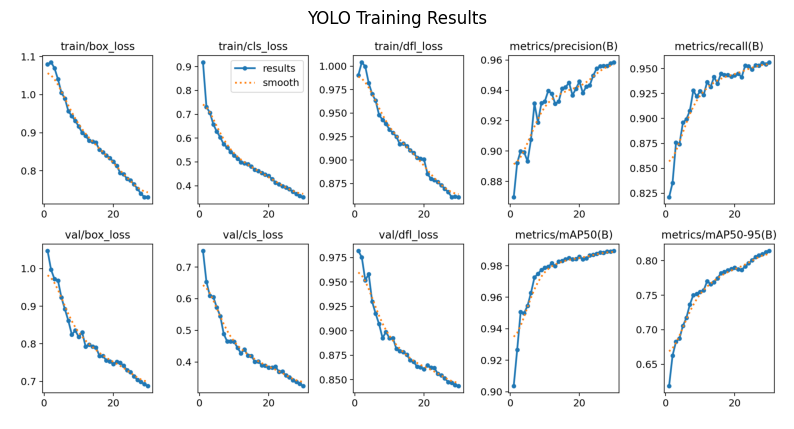

In [7]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(
"/content/drive/MyDrive/yolo_runs/vehicle_detection/results.png"
)

plt.figure(figsize=(10,6))
plt.imshow(img)
plt.axis("off")
plt.title("YOLO Training Results")

Confusion Matrix

Text(0.5, 1.0, 'Confusion Matrix')

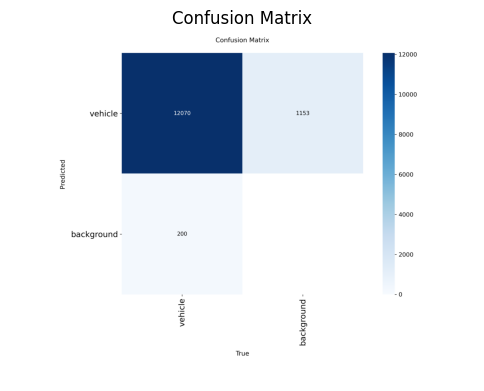

In [8]:
img = Image.open(
"/content/drive/MyDrive/yolo_runs/vehicle_detection/confusion_matrix.png"
)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title("Confusion Matrix")

Normalized Confusion Matrix

Text(0.5, 1.0, 'Normalized Confusion Matrix')

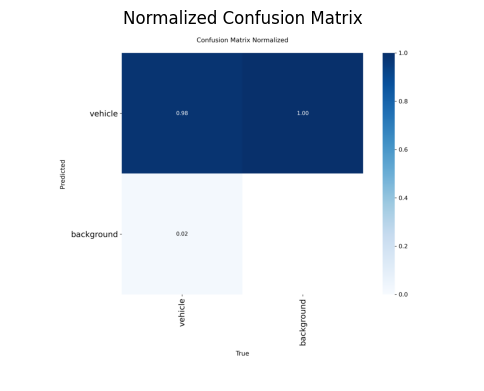

In [9]:
img = Image.open(
"/content/drive/MyDrive/yolo_runs/vehicle_detection/confusion_matrix_normalized.png"
)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title("Normalized Confusion Matrix")

Precision–Recall Curve (PR Curve)

Text(0.5, 1.0, 'Precision-Recall Curve')

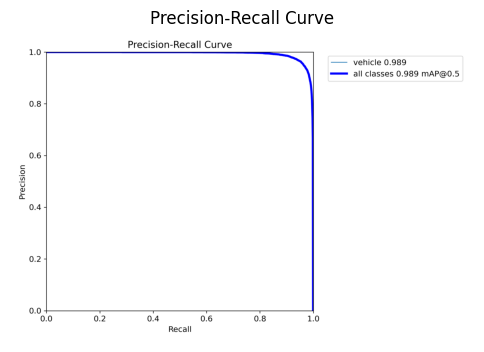

In [11]:
img = Image.open(
"/content/drive/MyDrive/yolo_runs/vehicle_detection/BoxPR_curve.png"
)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title("Precision-Recall Curve")

F1 Curve

Text(0.5, 1.0, 'F1 Score Curve')

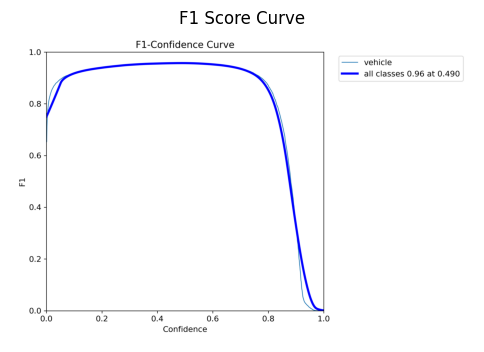

In [12]:
img = Image.open(
"/content/drive/MyDrive/yolo_runs/vehicle_detection/BoxF1_curve.png"
)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title("F1 Score Curve")

Final epoch statistics

In [13]:
import pandas as pd

df = pd.read_csv(
"/content/drive/MyDrive/yolo_runs/vehicle_detection/results.csv"
)

df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
25,26,3454.03,0.76441,0.38582,0.86958,0.95579,0.95321,0.98845,0.80531,0.71364,0.35138,0.85154,0.000350,0.000350,0.000350
26,27,3601.42,0.75275,0.37470,0.86606,0.95609,0.95297,0.98832,0.80763,0.70379,0.34279,0.84742,0.000284,0.000284,0.000284
27,28,3740.56,0.73986,0.36592,0.86067,0.95614,0.95550,0.98902,0.80930,0.69862,0.33727,0.84674,0.000218,0.000218,0.000218
28,29,3887.86,0.73104,0.35766,0.86117,0.95782,0.95436,0.98897,0.81211,0.69234,0.33072,0.84431,0.000152,0.000152,0.000152
29,30,4044.54,0.73047,0.35186,0.86049,0.95852,0.95632,0.98944,0.81406,0.68786,0.32424,0.84357,0.000086,0.000086,0.000086


Performance Metrics

In [14]:
last_row = df.iloc[-1]

print("Precision:", last_row['metrics/precision(B)'])
print("Recall:", last_row['metrics/recall(B)'])
print("mAP50:", last_row['metrics/mAP50(B)'])
print("mAP50-95:", last_row['metrics/mAP50-95(B)'])

Precision: 0.95852
Recall: 0.95632
mAP50: 0.98944
mAP50-95: 0.81406


Plot Metrics

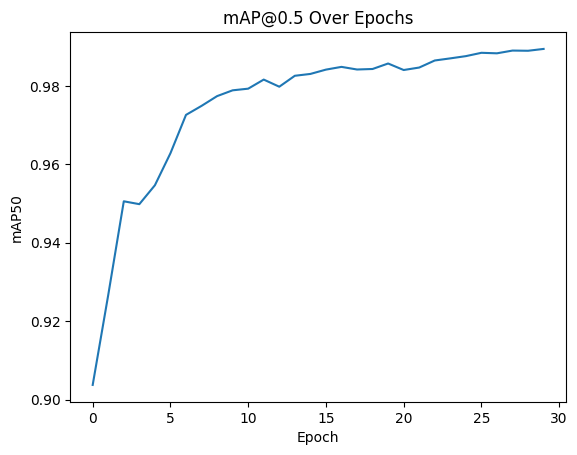

In [15]:
plt.plot(df['metrics/mAP50(B)'])

plt.title("mAP@0.5 Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("mAP50")

plt.show()

Plot Loss Curves

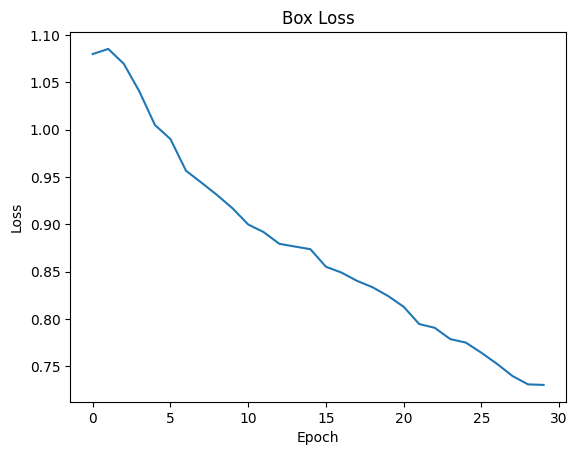

In [16]:
plt.plot(df['train/box_loss'])

plt.title("Box Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

In [17]:
!nvidia-smi

Sun Apr 19 17:57:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P0             28W /   70W |     609MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## **5. Vehicle Classification Using EfficientNetB0**

---

EfficientNetB0 is used for vehicle classification.
The dataset is prepared using image generators with augmentation to improve model generalization.

### 5.1 Data Augmentation

Data augmentation techniques such as rotation, zoom, flipping, and brightness adjustment are applied to increase dataset diversity and prevent overfitting.

### 5.2 Model Architecture Construction

EfficientNetB0 is used as the base model with pretrained ImageNet weights.
Custom dense layers are added for vehicle classification into five categories.

### 5.3 Model Compilation

The model is compiled using the Adam optimizer and sparse categorical crossentropy loss function.
Accuracy is used as the evaluation metric.

### 5.4 Phase 1 Training

In Phase 1, the base model layers are frozen and only the top classification layers are trained.
This allows the model to learn dataset-specific features.

### 5.5 Fine-Tuning the Model

Fine-tuning involves unfreezing selected layers of the base model.
This improves model performance by refining learned features.

## **6. Deployment Using Streamlit**

---

A Streamlit web application is created to allow users to upload images and detect vehicles in real time.
YOLO detects vehicles, and EfficientNet classifies them.

### 6.1 Public Deployment Using Ngrok

Ngrok is used to generate a public URL for accessing the Streamlit application from any device.

## **7. Conclusion**

This project successfully integrates YOLOv8 and EfficientNetB0 to detect and classify vehicles efficiently.
Apache Spark improves large-scale data processing, while Streamlit enables real-time deployment.

The system demonstrates the effectiveness of deep learning in intelligent transportation and vehicle monitoring applications.